# <span style="color:red"> Lecture 25 - Creating movies with matplotlib: Bayesian Updating  </span>

____________________

## <span style="color:red"> Bernoulli Random Variables </span>

## Flipping a coin

<font size = "4">

Suppose we flip a coin. Assuming the coin is fair, there is a 50% of getting "Heads" and 50% chance of getting "Tails". If we let $X$ be the outcome of the coin flip, we can write:

$$X = \begin{cases} \textrm{Heads},\qquad \textrm{w. probability 0.5}\\
\textrm{Tails},\qquad\ \  \textrm{w. probability 0.5}
\end{cases}$$


We can arbitrarily define one these results as "success" and the other as "failure". Let's choose "Heads" as our "success". Then we could also write:

$$X = \begin{cases} \textrm{Success},\qquad \textrm{w. probability 0.5}\\
\textrm{Failure},\qquad\textrm{w. probability 0.5}
\end{cases}$$

Better yet, we can choose numerical values. Let "Heads" = "success" = 1, and "Tails" = "failure" = 0. Then we can write:

$$X = \begin{cases} 1,\qquad \textrm{w. probability 0.5}\\
0,\qquad\textrm{w. probability 0.5}
\end{cases}$$

In this case we call $X$ a Bernoulii random variable with probability $p = 0.5$. We write this as:

$$ X \sim \textrm{Bernoulli}(p = 0.5)\quad \textrm{or }\quad X \sim \textrm{Bernoulli}(0.5)$$

## Shooting dice

<font size = "4">

Suppose we play an extremely simple dice game where two dice are rolled, resulting in a value from the range $2, 3, \dots, 11, 12$. Before the dice is rolled, we place a bet on what the value will be.

With an understanding of probability, you decide to place a bet on the most likely outcome, which is a "7". Then there is a 6/36 = 1/6 chance of winning the game, i.e. a "success". If we let $X$ be the outcome of the dice roll, then we can write:

$$X = \begin{cases} \textrm{Success},\qquad \textrm{w. probability 1/6}\\
\textrm{Failure},\qquad\textrm{w. probability 5/6}
\end{cases}$$

or

$$X = \begin{cases} 1,\qquad \textrm{w. probability 1/6}\\
0,\qquad\textrm{w. probability 5/6}
\end{cases}$$

Then $X$ is a Bernoulli random variable with probability $p = 1/6$. We can write this as:

$$ X \sim \textrm{Bernoulli}(p = 1/6)\quad \textrm{or }\quad X \sim \textrm{Bernoulli}(1/6)$$

## Medical Trial

<font size = "4">

After performing medical trials, a pharmaceutical company finds that a new antiobiotic is effective 85% of the time. So if a patient takes a treatment of this antibiotic, there is an 85% chance that it clears up a bacterial infection (a "success"). If $X$ is the outcome of the treatment, then we have:

$$X = \begin{cases} \textrm{Success},\qquad \textrm{w. probability 0.85 = 17/20}\\
\textrm{Failure},\qquad\textrm{w. probability 0.15 = 3/20}
\end{cases}$$

or

$$X = \begin{cases} 1,\qquad \textrm{w. probability 0.85 = 17/20}\\
0,\qquad\textrm{w. probability 0.15 = 3/20}
\end{cases}$$

Then $X$ is a Bernoulli random variable with probability $p = 17/20$. We can write this as:

$$ X \sim \textrm{Bernoulli}(p = 0.85)\quad \textrm{or }\quad X \sim \textrm{Bernoulli}(17/20)$$


## Certain events and impossible events

<font size = "4">

Consider the following random variables. 

- Let $S = 1$ if the sun rises tomorrow morning ("success"), and $S = 0$ if it doesn't ("failure"). Then, at least for the next few billion years or so, $S$ is a Bernouilli random variable with probability $p = 1$.

$$ S \sim \textrm{Bernoulli}(p = 1)\quad \textrm{or }\quad S \sim \textrm{Bernoulli}(1)$$

- Suppose a 24-year old politician runs for president of the United States in 2028. Let $W = 1$ if they are sworn in January 2029("success"), and $W = 0$ if they don't ("failure"). According to the U.S. constitution, no one under 35 can become president. Then $W$ is a Bernoulli random variable with probability $p = 0$. (This probability model is only valid if no constitutional amendments or revolutions occur before 2028.)

$$ W \sim \textrm{Bernoulli}(p = 0)\quad \textrm{or }\quad W \sim \textrm{Bernoulli}(0)$$

___________________________________________


## <span style="color:red"> Estimating the probability of a Bernoulli variable </span>

<font size = "4">

If we don't know the value of the probability $p$, how do we go about estimating its value? We can do so by performing independent experiments of the process.

- For example, suppose we want to test the efficacy of a drug for curing some illness.

- We give a large number $N$ of patients the drug and see how many recover. Let $X_i$ be the outcome of the $i$-th patient. I.e. $X_i = 1$ ("success") if the patient recovers, or $X_i = 0$ ("failure") if their condition does not improve.

- Then $X_i \sim \textrm{Bernoulli}(p)$ for $i=1,2,\dots, N$ where the probability $p$ is unknown.

- One way to estimate $p$ is to compute the average of the $N$ variables. Suppose that experiment $i$ has the outcome $X_i = x_i$ (where $x_i$ is either 0 or 1). Then we could estimate $p$ as:

$$\hat{p} = \frac{1}{N}\sum_{i=1}^{N}x_i$$

- We might not get all the results at the same time. Suppose the patients are ordered so that we get the results $X_1 = x_1, X_2 = x_2, X_3 = x_3, \dots, X_N = x_n$ in the same order. Then we could update our estimate with each new patient as follows:

    - $\hat{p}_1 = x_1$

    - $\hat{p}_2 = \frac{1}{2}(x_1 + x_2)$

    - $\hat{p}_3 = \frac{1}{3}\sum_{i=1}^3 x_i$

    - ...

    - $\hat{p}_{N-1} = \frac{1}{N-1}\sum_{i=1}^{N-1} x_i$

    - $\hat{p}_{N} = \frac{1}{N}\sum_{i=1}^{N} x_i$

- Let's simulate this in Python, where the true probability $p$ is equal to 0.7

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

p_true = 0.7
n_obs = 125

# reproducibility
np.random.seed(98124)

# generate observations
# The Bernouilli random variable is a special case of a "Binomial" random variable
obs = np.random.binomial(1, p_true, size = n_obs)

# each entry of obs is either a zero or a one.
display(obs)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1])

In [2]:
# compute a "cumulative sum" of the observations
obs_sum = obs.cumsum()

# divide by the number of observations at each step
obs_mean = obs_sum / np.arange(1, n_obs + 1)

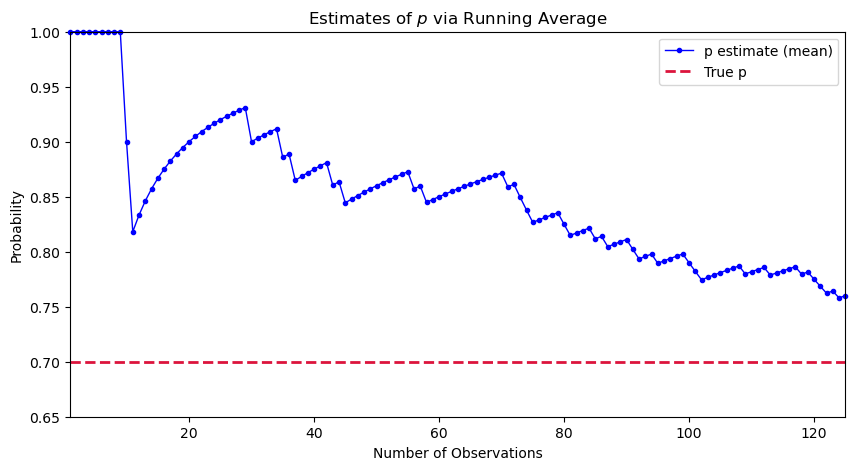

In [3]:
# Plot the running average against the number of observations

fig, ax = plt.subplots(figsize = (10, 5))
line_mean, = ax.plot([], [], lw = 1, color = "blue", label='p estimate (mean)',marker = '.',clip_on = False)

line_mean.set_data(np.arange(1,n_obs + 1), obs_mean)

ax.set_xlim(1, n_obs)
ax.set_ylim(0.65, 1)
ax.axhline(p_true, color='crimson', lw=2, ls='--', label='True p')
ax.set_xlabel("Number of Observations")
ax.set_ylabel("Probability")
ax.set_title("Estimates of $p$ via Running Average")
ax.legend()
plt.show()

## <span style="color:red"> Bayesian updates </span>

<font size = "4">

- Another approach to estimating $p$ is through **Bayesian updating**

- Instead of simply estimating $p$ at each step, we treat it as a random variable $P$, and update its distribution with the result of each experiment.

- We must choose what distribution we will use. Our choice will be the **Beta** distribution.

- The Beta distribution depends on two parameters $a > 0$ and $b > 0$. These can be any real numbers, but in the case where both are positive integers (i.e., $1,2,3,4,\dots$), then the probability density function is:

$$f_P(p; a, b) = \frac{(a + b - 1)!}{(a - 1)!(b-1)!}\cdot p^{a-1}(1 - p)^{b-1},\quad 0 \leq p \leq 1$$


Here are some properties of the Beta distribution:

- The probability that $P \leq p$ is:

$$ \textrm{Prob.}(P \leq p) = \int_0^p f_P(t;a,b)\ \textrm{d}t$$

- Note that for $p = 1$, we have:

$$ \textrm{Prob.}(P \leq 1) = \int_0^1 f_P(p;a,b)\ \textrm{d}p = 1$$

- The expected value (average value) of the random variable $P$ is:

$$ \mathbb{E}[P] = \int_0^1 p\cdot f_P(p;a, b)\ \textrm{d} p = \frac{a}{a + b}$$

- So we can also define an estimate for $P$ using the expected value as $\hat{p} = \frac{a}{a + b}$

- We can create a 95% confidence interval $[c_{\textrm{low}}, c_{\textrm{high}}]$ by defining

$$ \textrm{Prob.}(P \leq c_{\textrm{low}}) = 0.025, \qquad \textrm{Prob.}(P \leq c_{\textrm{high}}) = 0.975$$

- A 95% confidence interval means $\textrm{Prob.}(c_{\textrm{low}} \leq P \leq c_{\textrm{high}}) = 0.95$.

We'll start off by choosing $a_0 = 2$, $b_0 = 2$. This is called the **prior** distribution.

In [4]:
from scipy.stats import beta 

a_0, b_0 = 2, 2

# create pdf for the initial choices of a and b
prior_pdf = lambda x: beta.pdf(x, a_0, b_0)

# calculate expected value
p_0 = beta.mean(a_0, b_0)

# calculate 95% confidence interval using "percent point function"
c_low_0, c_high_0 = beta.ppf([0.025, 0.975], a_0, b_0)

print("Expected value:", p_0)
print("95% CI: [", round(c_low_0,2), ",", round(c_high_0, 2), "]")

Expected value: 0.5
95% CI: [ 0.09 , 0.91 ]


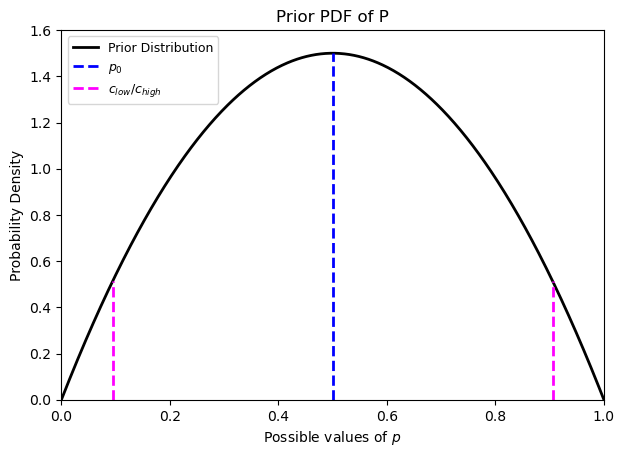

In [5]:
p_vals = np.linspace(0, 1, 800)

fig, ax = plt.subplots(figsize = (7, 4.8))
line_prior, = ax.plot([], [], lw = 2, color = "black", label='Prior Distribution')

line_prior.set_data(p_vals, prior_pdf(p_vals))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.6)
ax.vlines(p_0, 0, prior_pdf(p_0), color='blue', lw=2, ls='--', label='$p_0$')
ax.vlines(c_low_0, 0, prior_pdf(c_low_0), color='magenta', lw=2, ls='--', label='$c_{low}/c_{high}$')
ax.vlines(c_high_0, 0, prior_pdf(c_high_0), color='magenta', lw=2, ls='--', label='_no_legend')
ax.set_xlabel("Possible values of $p$")
ax.set_ylabel("Probability Density")
ax.set_title("Prior PDF of P")
ax.legend(fontsize = 9, loc = "upper left")
plt.show()

<font size = "4">

Now, after our first observation $X_1 = x_1$, we want to update the prior distribution to get the **posterior** distribution.

We need to define the following equations functions:

- $f_1(x_1|p) = \textrm{Prob.}(X_1 = x_1, \textrm{given that } P = p)$

- $f_1(x_1) = \textrm{Prob.}(X_1 = x_1)$

- Reinterpret $f_P(p ;a_0, b_0)$ as $\textrm{Prob.}(p\leq P \leq p + \Delta p)$ where $\Delta p$ is very small.

- $f_P(p|x_1) = \textrm{Prob.}(p \leq P \leq p + \Delta p, \textrm{given that } X_1 = x_1)$. This is the posterior distribution.

According to Bayes' rule, these functions are related by:

$$f_P(p|x_1) = \frac{f_1(x_1|p)\cdot f_P(p; a_0, b_0)}{f_1(x_1)}$$

It turns out that, when $X_1$ is a Bernoulli variable (given $P = p$) and $P$ has a Beta distribution, then the **posterior distribution** is also a Beta distribution where we replace $a_0$ by $a_0 + x_1$ and $b_0$ by $b_0 + 1 - x_1$

$$f_P(p|x_1) = f_P(p; a_0 + x_1, b_0 + 1 - x_1) = f_P(p; a_1, b_1)$$

In [6]:
# Outcome of first experiment
x_1 = obs[0]

# update parameters of distribution
a_1 = a_0 + x_1
b_1 = b_0 + 1 - x_1 

# create pdf for the updated values of a and b
pdf_1 = lambda x: beta.pdf(x, a_1, b_1)

# calculate expected value
p_1 = beta.mean(a_1, b_1)

# calculate 95% confidence interval using "percent point function"
c_low_1, c_high_1 = beta.ppf([0.025, 0.975], a_1, b_1)

print("a_1:", a_1, " b_1:", b_1)
print("Expected value:", p_1)
print("95% CI: [", round(c_low_1,2), ",", round(c_high_1, 2), "]")

a_1: 3  b_1: 2
Expected value: 0.6
95% CI: [ 0.19 , 0.93 ]


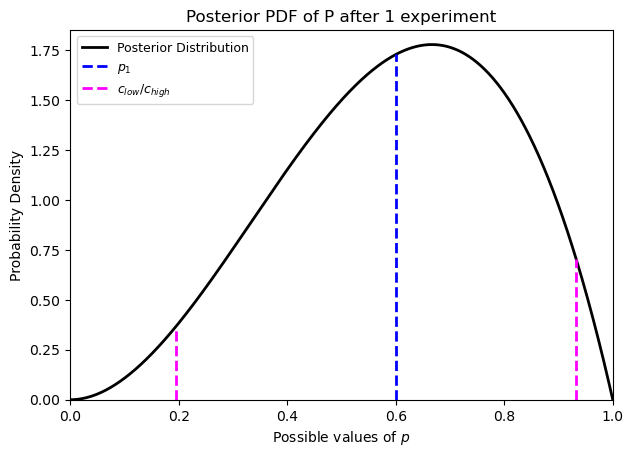

In [7]:
p_vals = np.linspace(0, 1, 800)

fig, ax = plt.subplots(figsize = (7, 4.8))
line_prior, = ax.plot([], [], lw = 2, color = "black", label='Posterior Distribution')

line_prior.set_data(p_vals, pdf_1(p_vals))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.85)
ax.vlines(p_1, 0, pdf_1(p_1), color='blue', lw=2, ls='--', label='$p_1$')
ax.vlines(c_low_1, 0, pdf_1(c_low_1), color='magenta', lw=2, ls='--', label='$c_{low}/c_{high}$')
ax.vlines(c_high_1, 0, pdf_1(c_high_1), color='magenta', lw=2, ls='--', label='_no_legend')
ax.set_xlabel("Possible values of $p$")
ax.set_ylabel("Probability Density")
ax.set_title("Posterior PDF of P after 1 experiment")
ax.legend(fontsize = 9)
plt.show()

<font size = "4">

After the 2nd experiment $X_2 = x_2$, we repeat the process and we get a new posterior distribution. It is also a Beta distribution with parameters:

- $a_2 = a_1 + x_2 = a_0 + x_1 + x_2$

- $b_2 = b_1 + 1 - x_2 = b_0 + 2 - x_1 - x_2$


In general, after $n$ experiments, we update the prior distribution $n$ times to get a new Beta distribution with parameters:

- $a_n = a_0 + \sum_{i=1}^n x_i$

- $b_n = b_0 + n - \sum_{i=1}^n x_i$



In [8]:
# outcome of 2nd experiment
x_2 = obs[1]

a_2 = a_0 + x_1 + x_2
b_2 = b_0 + 2 - x_1 - x_2

# create pdf for the updated values of a and b
pdf_2 = lambda x: beta.pdf(x, a_2, b_2)

# calculate expected value
p_2 = beta.mean(a_2, b_2)

# calculate 95% confidence interval using "percent point function"
c_low_2, c_high_2 = beta.ppf([0.025, 0.975], a_2, b_2)

print("a_2:", a_2, " b_2:", b_2)
print("Expected value:", p_2)
print("95% CI: [", round(c_low_2,2), ",", round(c_high_2, 2), "]")

a_2: 4  b_2: 2
Expected value: 0.6666666666666666
95% CI: [ 0.28 , 0.95 ]


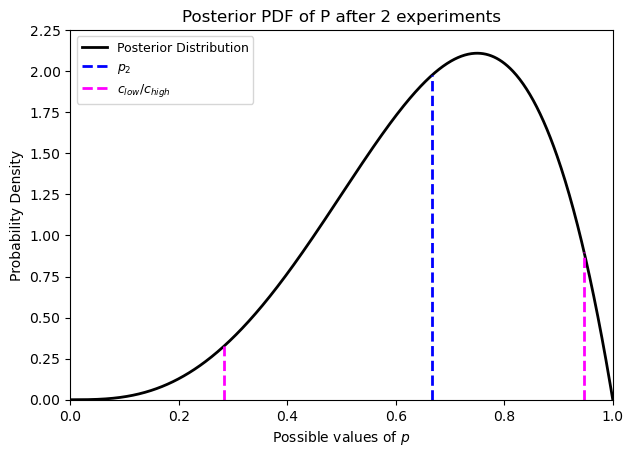

In [9]:
p_vals = np.linspace(0, 1, 800)

fig, ax = plt.subplots(figsize = (7, 4.8))
line_prior, = ax.plot([], [], lw = 2, color = "black", label='Posterior Distribution')

line_prior.set_data(p_vals, pdf_2(p_vals))

ax.set_xlim(0, 1)
ax.set_ylim(0, 2.25)
ax.vlines(p_2, 0, pdf_2(p_2), color='blue', lw=2, ls='--', label='$p_2$')
ax.vlines(c_low_2, 0, pdf_2(c_low_2), color='magenta', lw=2, ls='--', label='$c_{low}/c_{high}$')
ax.vlines(c_high_2, 0, pdf_2(c_high_2), color='magenta', lw=2, ls='--', label='_no_legend')
ax.set_xlabel("Possible values of $p$")
ax.set_ylabel("Probability Density")
ax.set_title("Posterior PDF of P after 2 experiments")
ax.legend(fontsize = 9)
plt.show()

In [10]:
# update after n experiments
n = 37

a_n = a_0 + obs[:n].sum()
b_n = b_0 + n - obs[:n].sum()

# create pdf for the updated values of a and b
pdf_n = lambda x: beta.pdf(x, a_n, b_n)

# calculate expected value
p_n = beta.mean(a_n, b_n)

# calculate 95% confidence interval using "percent point function"
c_low_n, c_high_n = beta.ppf([0.025, 0.975], a_n, b_n)

print("a_n:", a_n, " b_n:", b_n)
print("Expected value:", p_n)
print("95% CI: [", round(c_low_n,2), ",", round(c_high_n, 2), "]")

a_n: 34  b_n: 7
Expected value: 0.8292682926829268
95% CI: [ 0.7 , 0.93 ]


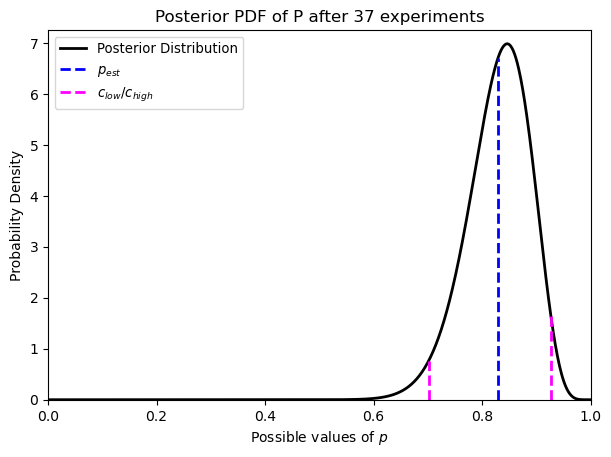

In [11]:
p_vals = np.linspace(0, 1, 800)

fig, ax = plt.subplots(figsize = (7, 4.8))
line_prior, = ax.plot([], [], lw = 2, color = "black", label='Posterior Distribution')

line_prior.set_data(p_vals, pdf_n(p_vals))

ax.set_xlim(0, 1)
ax.set_ylim(0, 7.25)
ax.vlines(p_n, 0, pdf_n(p_n), color='blue', lw=2, ls='--', label='$p_{est}$')
ax.vlines(c_low_n, 0, pdf_n(c_low_n), color='magenta', lw=2, ls='--', label='$c_{low}/c_{high}$')
ax.vlines(c_high_n, 0, pdf_n(c_high_n), color='magenta', lw=2, ls='--', label='_no_legend')
ax.set_xlabel("Possible values of $p$")
ax.set_ylabel("Probability Density")
ax.set_title(f"Posterior PDF of P after {n} experiments")
ax.legend(fontsize = 9.5)
plt.show()

## <span style="color:red"> Creating a movie to visualize Bayesian updating </span>

<font size = "4">

Our goal is to create a movie of the Bayesian updating process.

First, let's collect everything we need in a DataFrame.


In [12]:
import pandas as pd 

# Create a two column DataFrame
# trial: number of each experiment. "Experiment" 0 will correspond to the prior distribution. 
# result: the value of x_i from each experiment. Will make result 0 = np.nan 

df = pd.DataFrame({"trial" : np.arange(0, n_obs + 1), "result" : np.append(np.nan, obs)})

# Calculate number of cumulative successes (= x_1 + x_2 + x_3 + ... + x_n)
# Ignore the np.nan and put a zero instead at the beginning.
num_success = np.append(0, df["result"].cumsum()[1:])

# Create columns for the parameters "a_n" and "b_n"
df["a_n"] = a_0 + num_success # a_0 + (x_1 + x_2 + ... + x_n)
df["b_n"] = b_0 + df["trial"] - num_success # b_0 + n - (x_1 + x_2 + ... + x_n)

# Column for the estimate of p (the mean of the distribution)
df["p_est"] = beta.mean(df["a_n"], df["b_n"])

# Create a "plot" version
df_plot = df

In [13]:
display(df)

,trial,result,a_n,b_n,p_est
0,0,NaN,2.0,2.0,0.500000
1,1,1.0,3.0,2.0,0.600000
2,2,1.0,4.0,2.0,0.666667
3,3,1.0,5.0,2.0,0.714286
4,4,1.0,6.0,2.0,0.750000
...,...,...,...,...,...
121,121,0.0,95.0,30.0,0.760000
122,122,0.0,95.0,31.0,0.753968
123,123,1.0,96.0,31.0,0.755906
124,124,0.0,96.0,32.0,0.750000


<font size = "4">

We will use the function ``matplotlib.animation.FuncAnimation`` to create the movie. The movie is simply a collection of frames of still images. We will give it the following arguments:

- fig: a figure object we create ahead of time.

- func: a function we write that will tell FuncAnimation how to update the figure between frames.

- frames: the total number of still frames in the movie

- init_func: a function we write that will tell FuncAnimation how to initialize the figure before the first frame.

- interval: the number of milliseconds to delay between consecutive frames in the movie


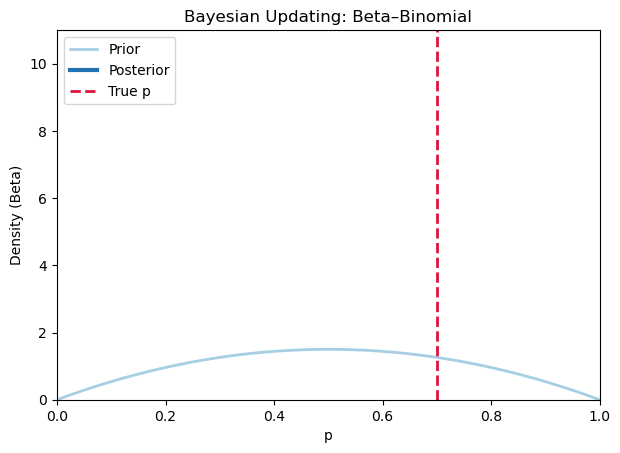

In [14]:
from matplotlib.animation import FuncAnimation

# create figure object
fig, ax = plt.subplots(figsize = (7, 4.8))

# Create blank lines. 
# Colors are hexadecimal codes
# Prior: (Red, Green, Blue) = ("9e", "ca", "e1") = (158, 202, 225) - light blue
# Posterior: (R, G, B) = ("21", "71", "b5") = (33, 113, 181) - deep blue
line_prior, = ax.plot([], [], lw = 2, color = "#9ecae1", label='Prior', alpha=0.9)
line_post,  = ax.plot([], [], lw=3, color='#2171b5', label='Posterior')

# True value of p
ax.axvline(p_true, color='crimson', lw=2, ls='--', label='True p')

# Set axis limits, labels, title, and create legend
ax.set_xlim(0, 1)
ax.set_ylim(0, 11)
ax.set_xlabel('p')
ax.set_ylabel('Density (Beta)')
ax.set_title('Bayesian Updating: Beta–Binomial')
ax.legend(loc='upper left')

# Create empty text that will eventually show: 
# (i) result of step n 
# (2) values of the Beta parameters and number of successes/failures
# (3) mean value of the posterior distribution and 95% confidence interval
text_step  = ax.text(0.01, 3.6, '', fontsize=9)
text_params= ax.text(0.01, 3.1, '', fontsize=9)
text_mean  = ax.text(0.01, 2.6, '', fontsize=9)

# Array of values for initial PDF
y_prior = beta.pdf(p_vals, a_0, b_0)

# initialization function
def init():
    # just plot prior distribution, set everything else as empty
    line_prior.set_data(p_vals, y_prior)
    line_post.set_data([], [])
    text_step.set_text('')
    text_params.set_text('')
    text_mean.set_text('')
    return line_prior, line_post, text_step, text_params, text_mean

# function to update between frames
def update(frame_idx):
    # grab parameters
    a_n = df_plot.loc[frame_idx, 'a_n']
    b_n = df_plot.loc[frame_idx, 'b_n']

    # calculate posterior distribution values, mean, and confidence interval
    y_post = beta.pdf(p_vals, a_n, b_n)
    mean_n = beta.mean(a_n, b_n)
    ci_low, ci_high = beta.ppf([0.025, 0.975], a_n, b_n)

    # plot posterior
    line_post.set_data(p_vals, y_post)

    # Calculate number of failures and successes
    t = df_plot.loc[frame_idx, "trial"]
    n_succ = df_plot.loc[:frame_idx, "result"].sum()
    n_fail = t - n_succ

    # Add text for the current frame
    if frame_idx == 0:
        text_step.set_text("Step 0")
    else:
        text_step.set_text(f'Step {t}: observed x_n={int(df_plot.loc[frame_idx, "result"])}')

    text_params.set_text(f'Post. Beta(a={a_n:.0f}, b={b_n:.0f}) | successes={int(n_succ)}, failures = {int(n_fail)}')
    text_mean.set_text(f'Post. mean={mean_n:.3f}, 95% CI = [{ci_low:.3f},{ci_high:.3f}]')

    return line_post, text_step, text_params, text_mean

# create animation object with 120 millisecond pause between frames
anim = FuncAnimation(fig = fig, func = update, frames = len(df_plot), init_func=init, interval=120)

<font size = "4">

We can convert to HTML and play the video in the notebook...

In [15]:
from IPython.display import HTML

HTML(anim.to_jshtml())

<font size = "4">

...or we can save it as a GIF...

In [16]:
from matplotlib.animation import PillowWriter

out_path = 'bayes_update.gif'

writer = PillowWriter(fps=12)
anim.save(out_path, writer=writer)


<font size = "4">

...or save it as an MP4. You must have "ffmpeg" installed on your computer however.

In [17]:
from matplotlib.animation import FFMpegWriter 

out_path = 'bayes_update.mp4'
writer = FFMpegWriter(fps=12, codec='libx264', bitrate=1800)

try:
    anim.save(out_path, writer=writer)
except:
    print("ffmpeg must be installed on your computer")


## <span style="color:red"> Good Luck with Finals! </span>